# 🔧 FASE 2B: FEATURE ENGINEERING COMPLETO

## __Objetivo__: Crear las variables alternativas que harán brillar y destacar a este proyecto + preparar datos para modelado.

---

#### Setup e Imports

In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
pd.set_option('display.max_columns', None)

print("=" * 80)
print("🔧 FEATURE ENGINEERING - MOTOR DE MICRO-PRÉSTAMOS INCLUSIVO")
print("=" * 80)
print("\n✅ Librerías importadas correctamente")

🔧 FEATURE ENGINEERING - MOTOR DE MICRO-PRÉSTAMOS INCLUSIVO

✅ Librerías importadas correctamente


#### Cargar Datos

In [3]:
# Cargar dataset original
df = pd.read_csv('../data/raw/application_train.csv')

print("\n📊 DATOS CARGADOS:")
print(f"   - Filas: {df.shape[0]:,}")
print(f"   - Columnas: {df.shape[1]}")
print(f"   - Target distribution: {df['TARGET'].value_counts(normalize=True).mul(100).round(2).to_dict()}")

# Crear copia para trabajar
df_fe = df.copy()

print("\n✅ Dataset copiado para Feature Engineering")


📊 DATOS CARGADOS:
   - Filas: 307,511
   - Columnas: 122
   - Target distribution: {0: 91.93, 1: 8.07}

✅ Dataset copiado para Feature Engineering


#### Transformaciones Temporales (Días → Años)

⏰ PASO 1: TRANSFORMACIONES TEMPORALES

✅ Variables temporales creadas:
   - AGE_YEARS: 307,511 valores válidos (100.0%)
   - EMPLOYMENT_YEARS: 307,511 valores válidos (100.0%)
   - ADDRESS_TENURE_YEARS: 307,511 valores válidos (100.0%)
   - ID_PUBLISH_YEARS: 307,511 valores válidos (100.0%)
   - PHONE_CHANGE_YEARS: 307,510 valores válidos (100.0%)


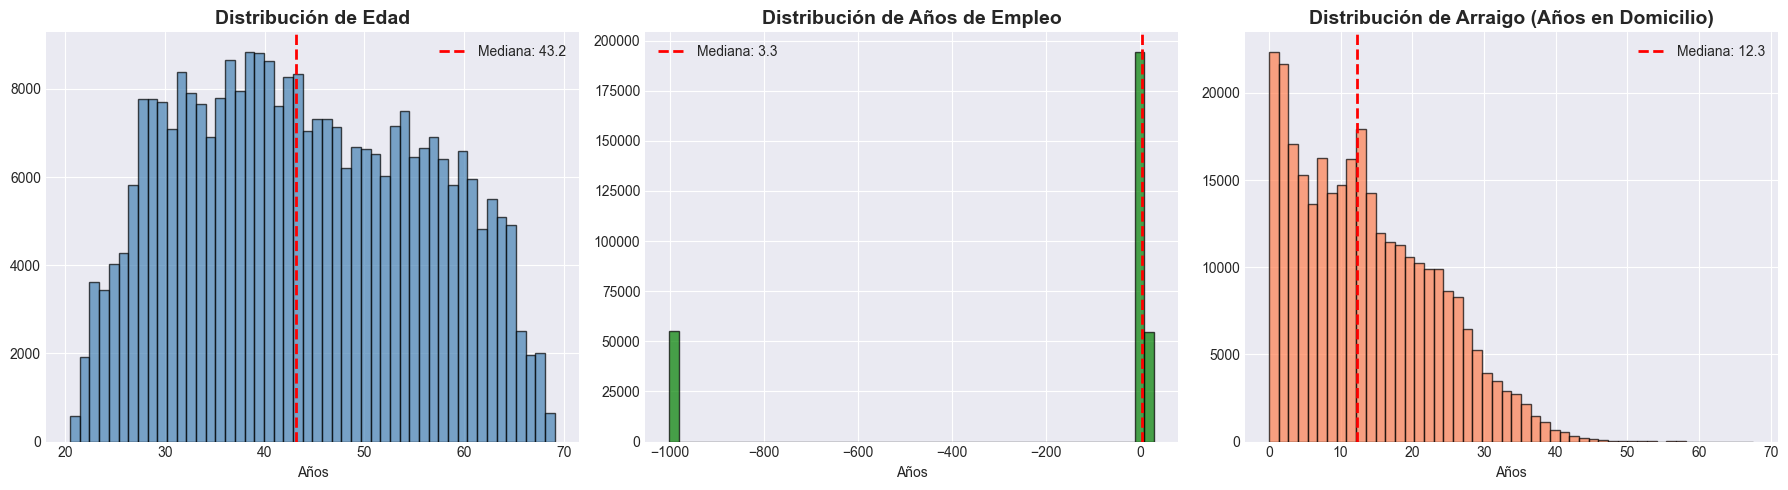


💡 INSIGHTS:
   - Edad promedio: 43.9 años
   - Experiencia laboral mediana: 3.3 años
   - Tiempo en domicilio mediano: 12.3 años


In [4]:
print("=" * 80)
print("⏰ PASO 1: TRANSFORMACIONES TEMPORALES")
print("=" * 80)

# 1. Edad en años (más interpretable que días)
df_fe['AGE_YEARS'] = (-df_fe['DAYS_BIRTH'] / 365).round(1)

# 2. Años de empleo (limpiar valor anómalo 365243)
df_fe['EMPLOYMENT_YEARS'] = -df_fe['DAYS_EMPLOYED'] / 365
df_fe.loc[df_fe['EMPLOYMENT_YEARS'] > 100, 'EMPLOYMENT_YEARS'] = np.nan  # Limpiar anómalo

# 3. Años en domicilio actual (arraigo)
df_fe['ADDRESS_TENURE_YEARS'] = (-df_fe['DAYS_REGISTRATION'] / 365).round(1)

# 4. Años desde última actualización de ID
df_fe['ID_PUBLISH_YEARS'] = (-df_fe['DAYS_ID_PUBLISH'] / 365).round(1)

# 5. Años desde último cambio de teléfono
df_fe['PHONE_CHANGE_YEARS'] = (-df_fe['DAYS_LAST_PHONE_CHANGE'] / 365).round(1)

print("\n✅ Variables temporales creadas:")
temporal_vars = ['AGE_YEARS', 'EMPLOYMENT_YEARS', 'ADDRESS_TENURE_YEARS', 
                 'ID_PUBLISH_YEARS', 'PHONE_CHANGE_YEARS']

for var in temporal_vars:
    non_null = df_fe[var].notna().sum()
    print(f"   - {var}: {non_null:,} valores válidos ({non_null/len(df_fe)*100:.1f}%)")

# Visualización rápida
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Edad
axes[0].hist(df_fe['AGE_YEARS'].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribución de Edad', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Años')
axes[0].axvline(df_fe['AGE_YEARS'].median(), color='red', linestyle='--', linewidth=2, 
                label=f'Mediana: {df_fe["AGE_YEARS"].median():.1f}')
axes[0].legend()

# Años de empleo
emp_clean = df_fe['EMPLOYMENT_YEARS'].dropna()
emp_clean = emp_clean[emp_clean <= emp_clean.quantile(0.99)]  # Quitar outliers para viz
axes[1].hist(emp_clean, bins=50, color='green', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribución de Años de Empleo', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Años')
axes[1].axvline(emp_clean.median(), color='red', linestyle='--', linewidth=2,
                label=f'Mediana: {emp_clean.median():.1f}')
axes[1].legend()

# Años en domicilio
axes[2].hist(df_fe['ADDRESS_TENURE_YEARS'].dropna(), bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[2].set_title('Distribución de Arraigo (Años en Domicilio)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Años')
axes[2].axvline(df_fe['ADDRESS_TENURE_YEARS'].median(), color='red', linestyle='--', linewidth=2,
                label=f'Mediana: {df_fe["ADDRESS_TENURE_YEARS"].median():.1f}')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"\n💡 INSIGHTS:")
print(f"   - Edad promedio: {df_fe['AGE_YEARS'].mean():.1f} años")
print(f"   - Experiencia laboral mediana: {emp_clean.median():.1f} años")
print(f"   - Tiempo en domicilio mediano: {df_fe['ADDRESS_TENURE_YEARS'].median():.1f} años")

#### Features Tradicionales (Ratios Financieros)


💰 PASO 2: FEATURES TRADICIONALES (RATIOS FINANCIEROS)

✅ Ratios financieros creados:
                          Media    Mediana  Desv. Est.
CREDIT_INCOME_RATIO       3.958      3.265       2.690
ANNUITY_INCOME_RATIO      0.181      0.163       0.095
CREDIT_GOODS_RATIO        1.123      1.119       0.124
EMPLOYMENT_AGE_RATIO     -2.920      0.089       6.627
INCOME_PER_CAPITA     93105.880  75000.000  101373.363
CHILDREN_RATIO            0.126      0.000       0.200


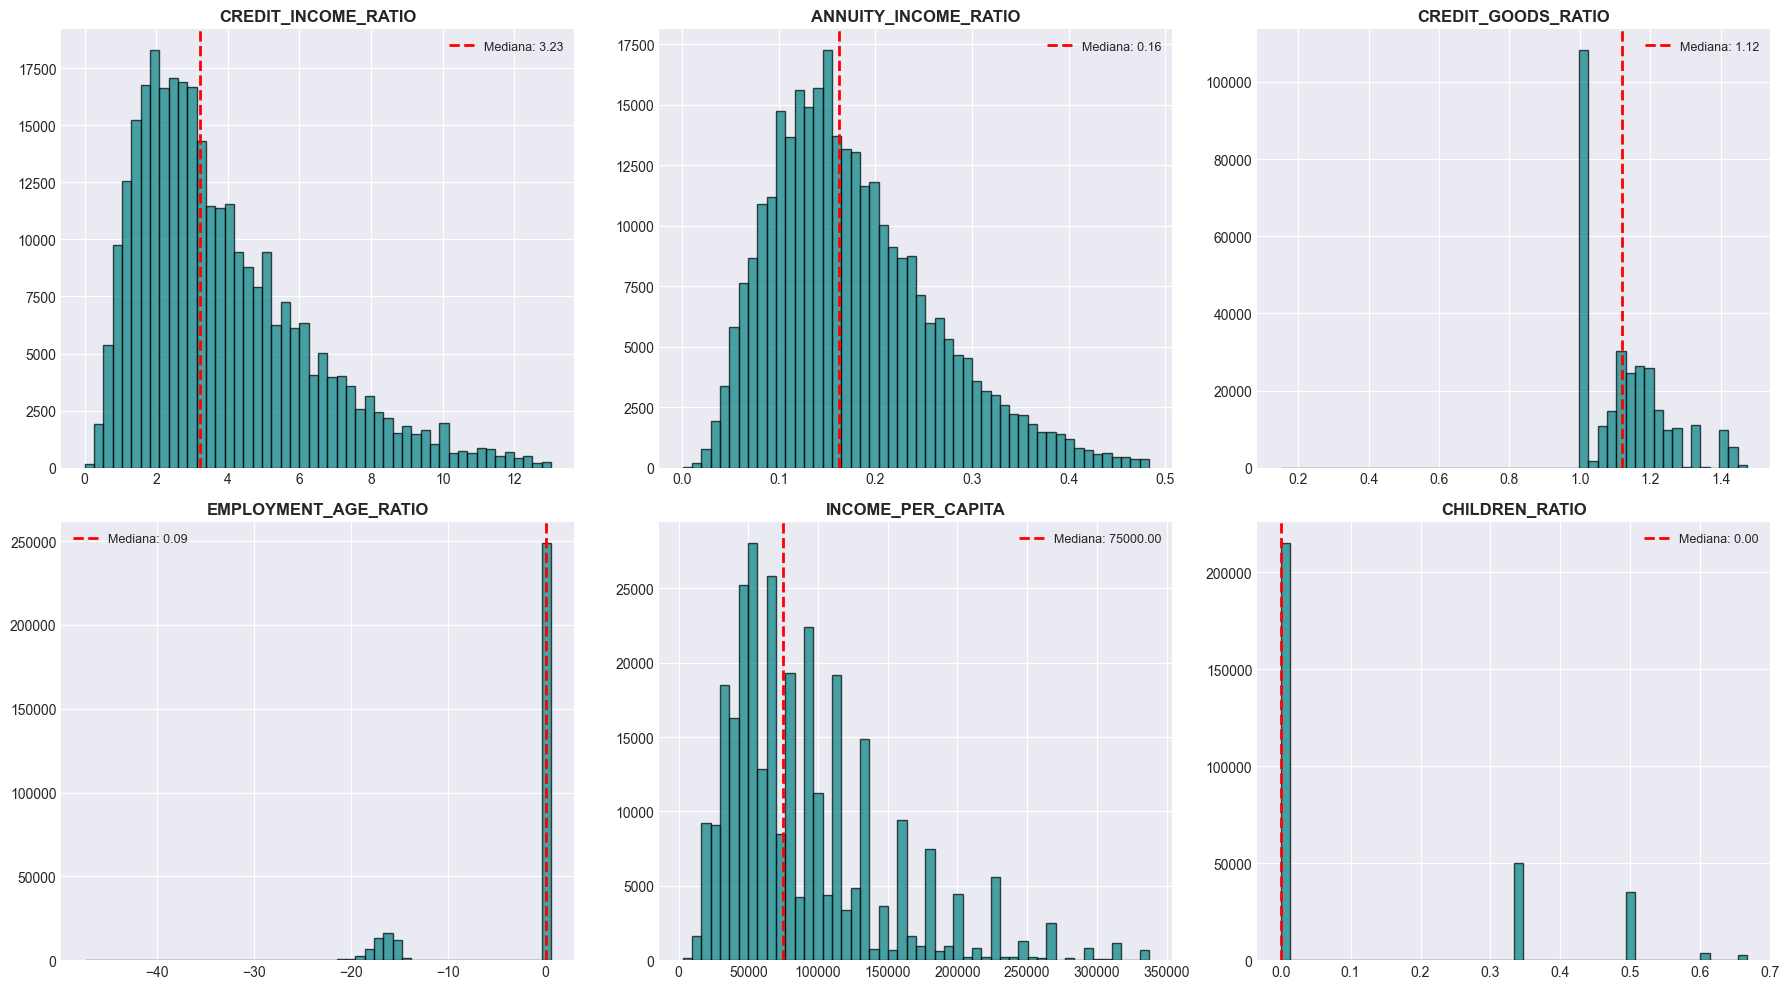


💡 INSIGHTS CLAVE:
   - Crédito promedio es 3.3x el ingreso anual
   - La cuota representa 16.3% del ingreso mensual
   - Ratio hijos/familia: 0.00


In [5]:
print("\n" + "=" * 80)
print("💰 PASO 2: FEATURES TRADICIONALES (RATIOS FINANCIEROS)")
print("=" * 80)

# 1. Ratio Crédito/Ingreso (capacidad de pago)
df_fe['CREDIT_INCOME_RATIO'] = df_fe['AMT_CREDIT'] / df_fe['AMT_INCOME_TOTAL']

# 2. Ratio Anualidad/Ingreso (peso de la cuota)
df_fe['ANNUITY_INCOME_RATIO'] = df_fe['AMT_ANNUITY'] / df_fe['AMT_INCOME_TOTAL']

# 3. Utilización del crédito (crédito solicitado vs precio del bien)
df_fe['CREDIT_GOODS_RATIO'] = df_fe['AMT_CREDIT'] / df_fe['AMT_GOODS_PRICE']

# 4. Días de empleo / Edad (estabilidad laboral relativa)
df_fe['EMPLOYMENT_AGE_RATIO'] = df_fe['EMPLOYMENT_YEARS'] / df_fe['AGE_YEARS']

# 5. Ingreso per cápita familiar
df_fe['INCOME_PER_CAPITA'] = df_fe['AMT_INCOME_TOTAL'] / df_fe['CNT_FAM_MEMBERS']

# 6. Ratio hijos/miembros familia (carga dependiente)
df_fe['CHILDREN_RATIO'] = df_fe['CNT_CHILDREN'] / df_fe['CNT_FAM_MEMBERS']

print("\n✅ Ratios financieros creados:")
ratio_vars = ['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_GOODS_RATIO',
              'EMPLOYMENT_AGE_RATIO', 'INCOME_PER_CAPITA', 'CHILDREN_RATIO']

stats = df_fe[ratio_vars].describe().T[['mean', '50%', 'std']]
stats.columns = ['Media', 'Mediana', 'Desv. Est.']
print(stats.round(3))

# Visualización
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, var in enumerate(ratio_vars):
    # Limpiar outliers extremos para visualización
    data_viz = df_fe[var].dropna()
    q99 = data_viz.quantile(0.99)
    data_viz = data_viz[data_viz <= q99]
    
    axes[i].hist(data_viz, bins=50, color='teal', edgecolor='black', alpha=0.7)
    axes[i].set_title(var, fontsize=12, fontweight='bold')
    axes[i].axvline(data_viz.median(), color='red', linestyle='--', linewidth=2,
                    label=f'Mediana: {data_viz.median():.2f}')
    axes[i].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n💡 INSIGHTS CLAVE:")
print(f"   - Crédito promedio es {df_fe['CREDIT_INCOME_RATIO'].median():.1f}x el ingreso anual")
print(f"   - La cuota representa {df_fe['ANNUITY_INCOME_RATIO'].median()*100:.1f}% del ingreso mensual")
print(f"   - Ratio hijos/familia: {df_fe['CHILDREN_RATIO'].median():.2f}")

#### FEATURES ALTERNATIVOS (El Diferenciador) - Parte 1

In [6]:
print("\n" + "=" * 80)
print("🌟 PASO 3: FEATURES ALTERNATIVOS (INNOVACIÓN)")
print("=" * 80)
print("Estas variables son las que diferencian nuestro modelo inclusivo\n")

# ============================================================================
# 1. INCOME STABILITY SCORE (Estabilidad de ingresos)
# ============================================================================
print("1️⃣ INCOME STABILITY SCORE")

# Lógica: Tipos de ingreso más estables tienen mayor score
income_stability_map = {
    'Working': 0.7,              # Empleo formal: estabilidad media-alta
    'State servant': 0.9,        # Empleado público: muy estable
    'Pensioner': 0.95,           # Pensionado: máxima estabilidad
    'Commercial associate': 0.6, # Comerciante: estabilidad media
    'Businessman': 0.4,          # Empresario: variable
    'Maternity leave': 0.5,      # Licencia: temporal
    'Unemployed': 0.1,           # Desempleado: muy inestable
    'Student': 0.2               # Estudiante: sin ingresos estables
}

df_fe['INCOME_STABILITY_SCORE'] = df_fe['NAME_INCOME_TYPE'].map(income_stability_map)

# Ajustar por años de empleo (más años = más estabilidad)
df_fe['INCOME_STABILITY_SCORE_ADJ'] = df_fe['INCOME_STABILITY_SCORE'].copy()

# Bonus por experiencia laboral (máximo +0.2 puntos)
employment_bonus = (df_fe['EMPLOYMENT_YEARS'] / 10).clip(upper=0.2)
df_fe['INCOME_STABILITY_SCORE_ADJ'] = (
    df_fe['INCOME_STABILITY_SCORE_ADJ'] + employment_bonus.fillna(0)
).clip(upper=1.0)

print(f"   ✅ Score base creado (0-1)")
print(f"   ✅ Ajustado por experiencia laboral")
print(f"   Media: {df_fe['INCOME_STABILITY_SCORE_ADJ'].mean():.3f}")
print(f"   Mediana: {df_fe['INCOME_STABILITY_SCORE_ADJ'].median():.3f}")

# ============================================================================
# 2. EMPLOYMENT STABILITY SCORE (Estabilidad laboral)
# ============================================================================
print("\n2️⃣ EMPLOYMENT STABILITY SCORE")

# Normalizar años de empleo a escala 0-1
max_years = 20  # 20+ años = máxima estabilidad
df_fe['EMPLOYMENT_STABILITY'] = (df_fe['EMPLOYMENT_YEARS'] / max_years).clip(upper=1.0)

print(f"   ✅ Score normalizado (0-1)")
print(f"   Media: {df_fe['EMPLOYMENT_STABILITY'].mean():.3f}")
print(f"   Mediana: {df_fe['EMPLOYMENT_STABILITY'].median():.3f}")

# ============================================================================
# 3. ADDRESS TENURE SCORE (Arraigo residencial)
# ============================================================================
print("\n3️⃣ ADDRESS TENURE SCORE (Arraigo)")

# Normalizar años en domicilio
max_tenure = 15  # 15+ años = máximo arraigo
df_fe['ADDRESS_TENURE_SCORE'] = (df_fe['ADDRESS_TENURE_YEARS'] / max_tenure).clip(upper=1.0)

# Penalizar si vive en región diferente a trabajo
region_penalty = df_fe['REG_REGION_NOT_WORK_REGION'].fillna(0) * 0.1
df_fe['ADDRESS_TENURE_SCORE'] = (df_fe['ADDRESS_TENURE_SCORE'] - region_penalty).clip(lower=0)

print(f"   ✅ Score normalizado con penalización por movilidad")
print(f"   Media: {df_fe['ADDRESS_TENURE_SCORE'].mean():.3f}")
print(f"   Mediana: {df_fe['ADDRESS_TENURE_SCORE'].median():.3f}")

print("\n" + "-" * 80)


🌟 PASO 3: FEATURES ALTERNATIVOS (INNOVACIÓN)
Estas variables son las que diferencian nuestro modelo inclusivo

1️⃣ INCOME STABILITY SCORE
   ✅ Score base creado (0-1)
   ✅ Ajustado por experiencia laboral
   Media: -17.144
   Mediana: 0.844

2️⃣ EMPLOYMENT STABILITY SCORE
   ✅ Score normalizado (0-1)
   Media: -8.755
   Mediana: 0.166

3️⃣ ADDRESS TENURE SCORE (Arraigo)
   ✅ Score normalizado con penalización por movilidad
   Media: 0.677
   Mediana: 0.820

--------------------------------------------------------------------------------


#### FEATURES ALTERNATIVOS - Parte 2

In [7]:
# ============================================================================
# 4. FINANCIAL INCLUSION SCORE (Inclusión financiera/digital)
# ============================================================================
print("4️⃣ FINANCIAL INCLUSION SCORE")

# Flags de documentos y contacto (cada uno suma puntos)
flag_cols = [
    'FLAG_MOBIL',           # Tiene móvil
    'FLAG_EMP_PHONE',       # Tiene teléfono laboral
    'FLAG_WORK_PHONE',      # Tiene teléfono de trabajo
    'FLAG_CONT_MOBILE',     # Teléfono móvil de contacto
    'FLAG_PHONE',           # Tiene teléfono
    'FLAG_EMAIL',           # Tiene email
    'FLAG_DOCUMENT_2',      # Documento 2
    'FLAG_DOCUMENT_3',      # Documento 3
    'FLAG_DOCUMENT_4',      # Documento 4
    'FLAG_DOCUMENT_5',      # Documento 5
    'FLAG_DOCUMENT_6',      # Documento 6
    'FLAG_DOCUMENT_7',      # Documento 7
    'FLAG_DOCUMENT_8',      # Documento 8
]

# Sumar todos los flags (más flags = más inclusión)
df_fe['FINANCIAL_INCLUSION_SCORE'] = df_fe[flag_cols].sum(axis=1)

# Normalizar a 0-1
max_flags = len(flag_cols)
df_fe['FINANCIAL_INCLUSION_SCORE'] = df_fe['FINANCIAL_INCLUSION_SCORE'] / max_flags

print(f"   ✅ Score basado en {len(flag_cols)} flags de documentación/contacto")
print(f"   Media: {df_fe['FINANCIAL_INCLUSION_SCORE'].mean():.3f}")
print(f"   Mediana: {df_fe['FINANCIAL_INCLUSION_SCORE'].median():.3f}")

# ============================================================================
# 5. EXTERNAL SOURCES COMBINED (Scores externos combinados)
# ============================================================================
print("\n5️⃣ EXTERNAL SOURCES COMBINED SCORE")

# EXT_SOURCE_1, 2, 3 son scores externos (ya normalizados 0-1)
# Crear promedio ponderado (dando más peso al más correlacionado: EXT_SOURCE_3)
ext_sources = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

# Pesos basados en correlaciones del EDA (-0.155, -0.160, -0.179)
weights = [0.3, 0.3, 0.4]  # Mayor peso a EXT_SOURCE_3

df_fe['EXT_SOURCE_COMBINED'] = (
    df_fe['EXT_SOURCE_1'].fillna(0.5) * weights[0] +
    df_fe['EXT_SOURCE_2'].fillna(0.5) * weights[1] +
    df_fe['EXT_SOURCE_3'].fillna(0.5) * weights[2]
)

print(f"   ✅ Score combinado con pesos [0.3, 0.3, 0.4]")
print(f"   Media: {df_fe['EXT_SOURCE_COMBINED'].mean():.3f}")
print(f"   Mediana: {df_fe['EXT_SOURCE_COMBINED'].median():.3f}")

# ============================================================================
# 6. CREDIT BUREAU ACTIVITY (Actividad en bureau de crédito)
# ============================================================================
print("\n6️⃣ CREDIT BUREAU ACTIVITY SCORE")

# Suma de consultas en diferentes periodos (indica actividad crediticia)
bureau_cols = [
    'AMT_REQ_CREDIT_BUREAU_HOUR',
    'AMT_REQ_CREDIT_BUREAU_DAY',
    'AMT_REQ_CREDIT_BUREAU_WEEK',
    'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_QRT',
    'AMT_REQ_CREDIT_BUREAU_YEAR'
]

df_fe['CREDIT_BUREAU_ACTIVITY'] = df_fe[bureau_cols].sum(axis=1)

# Normalizar (pocas consultas = bueno, muchas = riesgo)
# Invertir escala: 0 consultas = 1.0, muchas consultas = 0.0
max_queries = 10
df_fe['CREDIT_BUREAU_SCORE'] = 1 - (df_fe['CREDIT_BUREAU_ACTIVITY'] / max_queries).clip(upper=1.0)

print(f"   ✅ Score inverso (menos consultas = mejor)")
print(f"   Media: {df_fe['CREDIT_BUREAU_SCORE'].mean():.3f}")
print(f"   Mediana: {df_fe['CREDIT_BUREAU_SCORE'].median():.3f}")

# ============================================================================
# 7. FAMILY DEPENDENCY RATIO (Carga familiar)
# ============================================================================
print("\n7️⃣ FAMILY DEPENDENCY RATIO")

# Ya creado en features tradicionales, pero lo categorizamos
df_fe['FAMILY_DEPENDENCY_CATEGORY'] = pd.cut(
    df_fe['CHILDREN_RATIO'],
    bins=[-0.01, 0, 0.33, 0.66, 1.0],
    labels=['Sin hijos', 'Carga baja', 'Carga media', 'Carga alta']
)

print(f"   ✅ Categorizado en 4 niveles")
print(f"\n   Distribución:")
print(df_fe['FAMILY_DEPENDENCY_CATEGORY'].value_counts())

# ============================================================================
# 8. PAYMENT BURDEN SCORE (Peso de la deuda)
# ============================================================================
print("\n8️⃣ PAYMENT BURDEN SCORE")

# Combinar múltiples indicadores de carga de pago
# Score bajo = mayor carga (riesgo)

# Normalizar ratio anualidad/ingreso (invertir: menos carga = mejor)
df_fe['PAYMENT_BURDEN_SCORE'] = 1 - df_fe['ANNUITY_INCOME_RATIO'].clip(upper=1.0)

# Ajustar por ratio crédito/ingreso
credit_burden = df_fe['CREDIT_INCOME_RATIO'] / 10  # Normalizar (asumiendo max ~10)
df_fe['PAYMENT_BURDEN_SCORE'] = (
    df_fe['PAYMENT_BURDEN_SCORE'] - credit_burden.clip(upper=0.5)
).clip(lower=0, upper=1)

print(f"   ✅ Score combinado de carga de pago (0=alta carga, 1=baja carga)")
print(f"   Media: {df_fe['PAYMENT_BURDEN_SCORE'].mean():.3f}")
print(f"   Mediana: {df_fe['PAYMENT_BURDEN_SCORE'].median():.3f}")

print("\n" + "=" * 80)
print("✅ TODOS LOS FEATURES ALTERNATIVOS CREADOS")
print("=" * 80)

4️⃣ FINANCIAL INCLUSION SCORE
   ✅ Score basado en 13 flags de documentación/contacto
   Media: 0.327
   Mediana: 0.308

5️⃣ EXTERNAL SOURCES COMBINED SCORE
   ✅ Score combinado con pesos [0.3, 0.3, 0.4]
   Media: 0.508
   Mediana: 0.517

6️⃣ CREDIT BUREAU ACTIVITY SCORE
   ✅ Score inverso (menos consultas = mejor)
   Media: 0.787
   Mediana: 0.800

7️⃣ FAMILY DEPENDENCY RATIO
   ✅ Categorizado en 4 niveles

   Distribución:
FAMILY_DEPENDENCY_CATEGORY
Sin hijos      215369
Carga media     89003
Carga alta       3137
Carga baja          0
Name: count, dtype: int64

8️⃣ PAYMENT BURDEN SCORE
   ✅ Score combinado de carga de pago (0=alta carga, 1=baja carga)
   Media: 0.491
   Mediana: 0.503

✅ TODOS LOS FEATURES ALTERNATIVOS CREADOS


#### Visualización de Features Alternativos


📊 VISUALIZACIÓN DE FEATURES ALTERNATIVOS



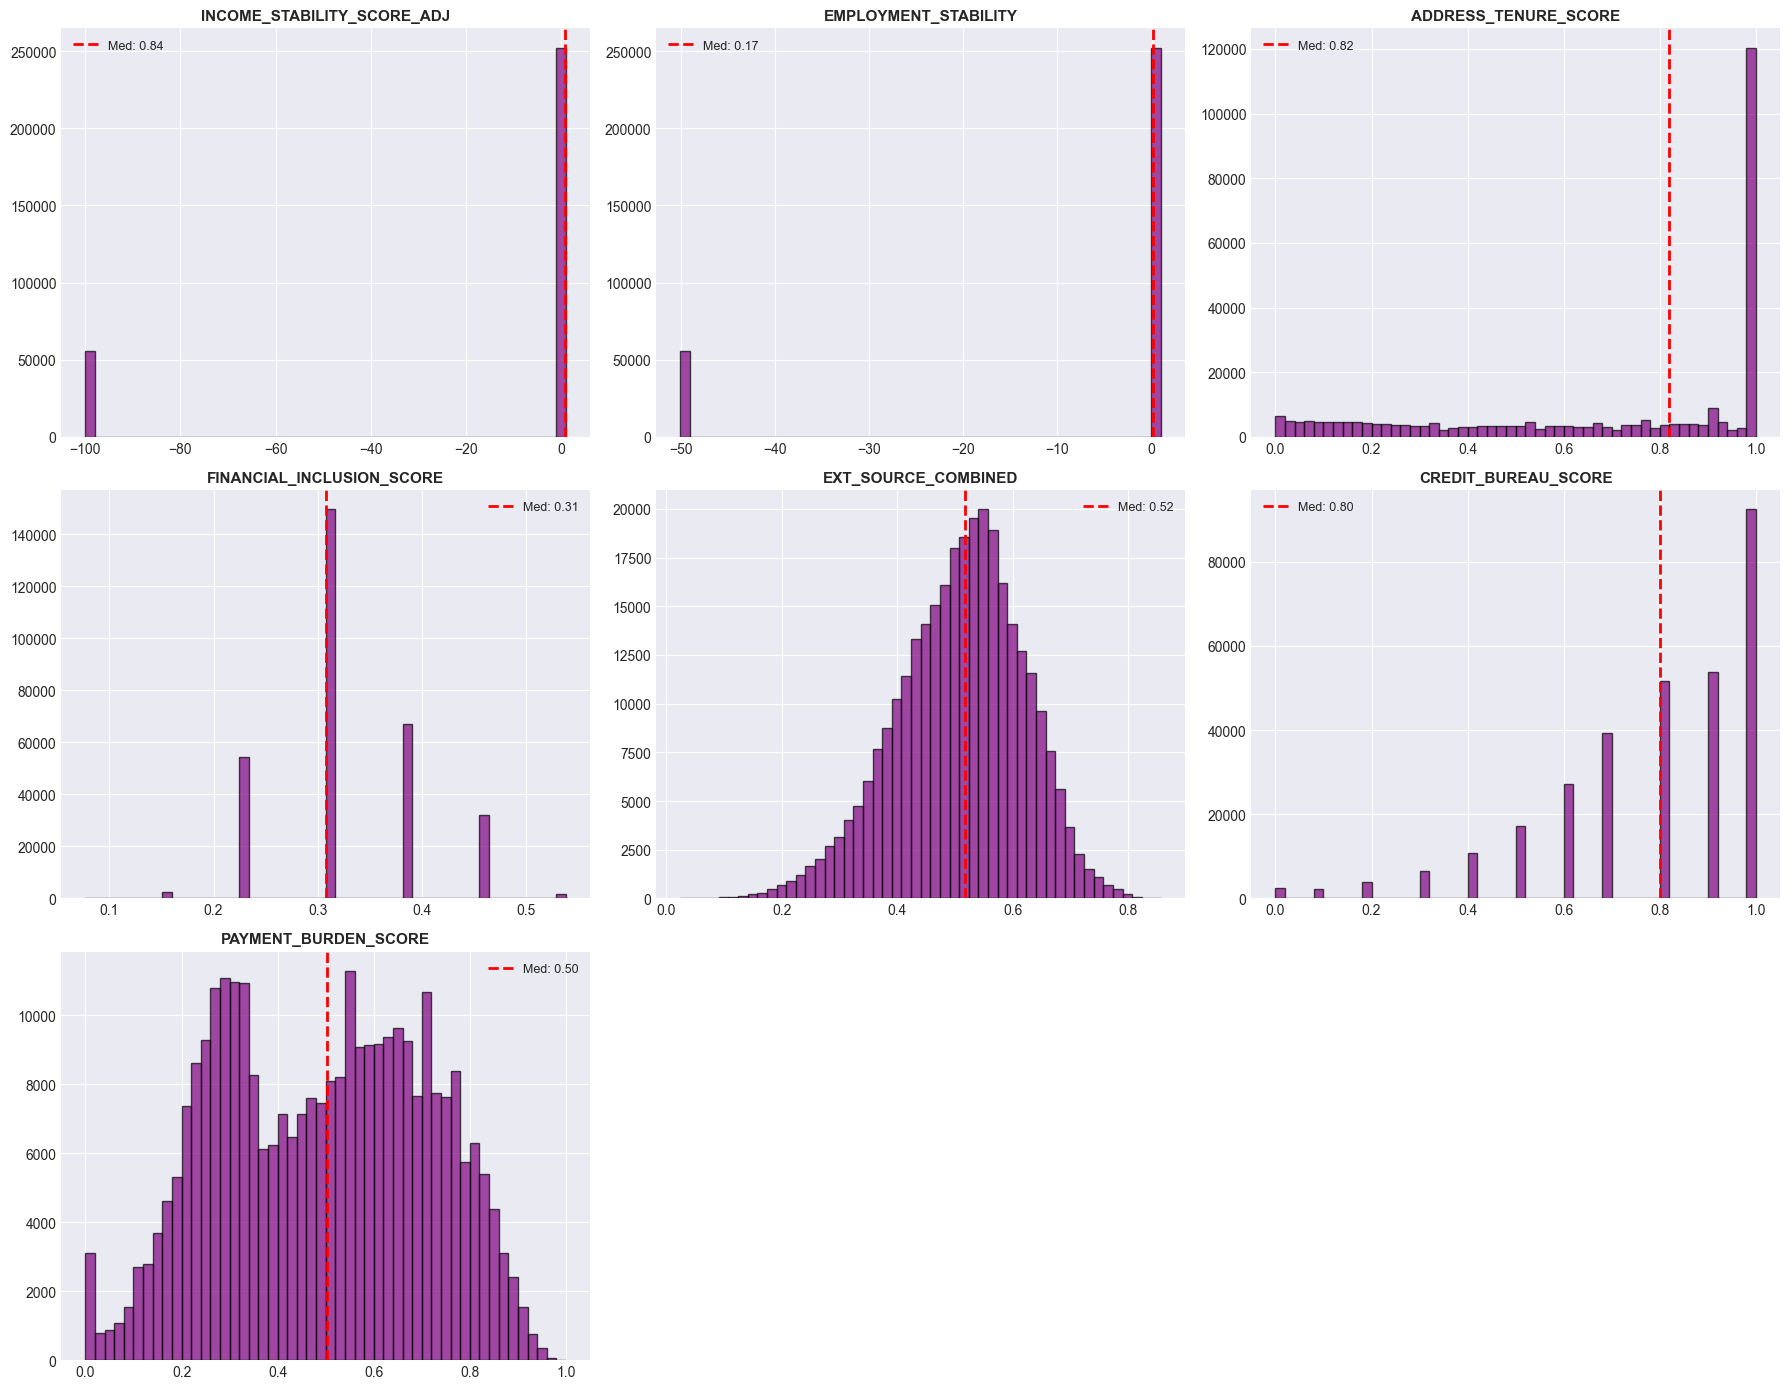


🎯 CORRELACIÓN DE FEATURES ALTERNATIVOS CON TARGET:

TARGET                        1.000000
INCOME_STABILITY_SCORE_ADJ    0.045948
EMPLOYMENT_STABILITY          0.045059
FINANCIAL_INCLUSION_SCORE     0.030357
CREDIT_BUREAU_SCORE           0.002443
PAYMENT_BURDEN_SCORE         -0.006278
ADDRESS_TENURE_SCORE         -0.032993
EXT_SOURCE_COMBINED          -0.222489


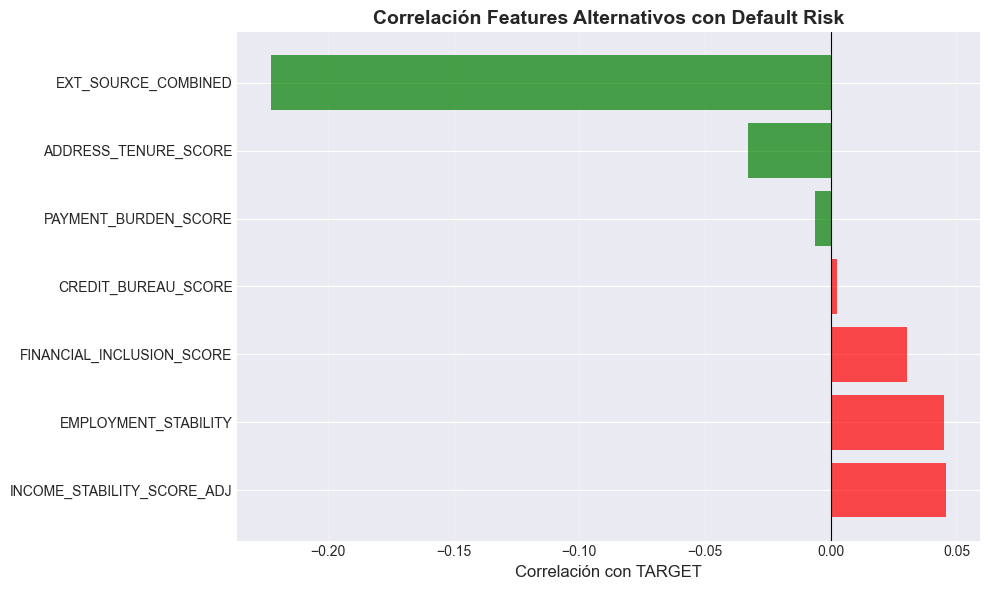

In [8]:
print("\n📊 VISUALIZACIÓN DE FEATURES ALTERNATIVOS\n")

alternative_features = [
    'INCOME_STABILITY_SCORE_ADJ',
    'EMPLOYMENT_STABILITY',
    'ADDRESS_TENURE_SCORE',
    'FINANCIAL_INCLUSION_SCORE',
    'EXT_SOURCE_COMBINED',
    'CREDIT_BUREAU_SCORE',
    'PAYMENT_BURDEN_SCORE'
]

# Distribuciones
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, feature in enumerate(alternative_features):
    axes[i].hist(df_fe[feature].dropna(), bins=50, color='purple', 
                 edgecolor='black', alpha=0.7)
    axes[i].set_title(feature, fontsize=11, fontweight='bold')
    axes[i].axvline(df_fe[feature].median(), color='red', linestyle='--', 
                    linewidth=2, label=f'Med: {df_fe[feature].median():.2f}')
    axes[i].legend(fontsize=9)

# Ocultar últimos subplots vacíos
for i in range(len(alternative_features), 9):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Correlación con TARGET
print("\n🎯 CORRELACIÓN DE FEATURES ALTERNATIVOS CON TARGET:\n")
correlations = df_fe[alternative_features + ['TARGET']].corr()['TARGET'].sort_values(ascending=False)
print(correlations.to_string())

# Visualización de correlaciones
plt.figure(figsize=(10, 6))
colors = ['green' if x < 0 else 'red' for x in correlations.drop('TARGET').values]
plt.barh(correlations.drop('TARGET').index, correlations.drop('TARGET').values, 
         color=colors, alpha=0.7)
plt.xlabel('Correlación con TARGET', fontsize=12)
plt.title('Correlación Features Alternativos con Default Risk', fontsize=14, fontweight='bold')
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

#### Manejo de Missing Values

In [9]:
print("\n" + "=" * 80)
print("❌ PASO 4: MANEJO DE MISSING VALUES")
print("=" * 80)

# Análisis de missing en features creados
new_features = temporal_vars + ratio_vars + alternative_features

missing_new = pd.DataFrame({
    'feature': new_features,
    'missing_count': df_fe[new_features].isnull().sum(),
    'missing_pct': (df_fe[new_features].isnull().sum() / len(df_fe) * 100).round(2)
})

missing_new = missing_new[missing_new['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print(f"\n📊 Features con missing values: {len(missing_new)}/{len(new_features)}")
if len(missing_new) > 0:
    print("\nTop features con missing:")
    print(missing_new.head(10).to_string(index=False))

# ESTRATEGIA DE IMPUTACIÓN

print("\n APLICANDO ESTRATEGIA DE IMPUTACIÓN:\n")

# 1. Variables numéricas con baja missing (<10%): Mediana
low_missing_num = missing_new[missing_new['missing_pct'] < 10]['feature'].tolist()
if low_missing_num:
    for col in low_missing_num:
        if col in df_fe.columns:
            median_val = df_fe[col].median()
            df_fe[col].fillna(median_val, inplace=True)
            print(f"   ✅ {col}: Imputado con mediana ({median_val:.3f})")

# 2. Scores que deberían ser 0.5 (neutral) si son missing
neutral_features = ['EXT_SOURCE_COMBINED', 'INCOME_STABILITY_SCORE_ADJ', 
                    'EMPLOYMENT_STABILITY', 'ADDRESS_TENURE_SCORE']
for col in neutral_features:
    if df_fe[col].isnull().sum() > 0:
        df_fe[col].fillna(0.5, inplace=True)
        print(f"   ✅ {col}: Imputado con 0.5 (neutral)")

# 3. OCCUPATION_TYPE: Crear categoría "Unknown"
if df_fe['OCCUPATION_TYPE'].isnull().sum() > 0:
    df_fe['OCCUPATION_TYPE'].fillna('Unknown', inplace=True)
    print(f"   ✅ OCCUPATION_TYPE: Missing → 'Unknown'")

# 4. Variables categóricas otras: Moda
categorical_cols = df_fe.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df_fe[col].isnull().sum() > 0:
        mode_val = df_fe[col].mode()[0]
        df_fe[col].fillna(mode_val, inplace=True)
        print(f"   ✅ {col}: Imputado con moda ('{mode_val}')")

# Verificación final
total_missing = df_fe.isnull().sum().sum()
print(f"\n📊 VERIFICACIÓN FINAL:")
print(f"   Total de missing values restantes: {total_missing:,}")

if total_missing > 0:
    remaining = df_fe.isnull().sum()
    remaining = remaining[remaining > 0].sort_values(ascending=False)
    print(f"\n   Columnas con missing restantes:")
    print(remaining.head(10))


❌ PASO 4: MANEJO DE MISSING VALUES

📊 Features con missing values: 6/18

Top features con missing:
             feature  missing_count  missing_pct
  CREDIT_GOODS_RATIO            278         0.09
  PHONE_CHANGE_YEARS              1         0.00
ANNUITY_INCOME_RATIO             12         0.00
   INCOME_PER_CAPITA              2         0.00
      CHILDREN_RATIO              2         0.00
PAYMENT_BURDEN_SCORE             12         0.00

 APLICANDO ESTRATEGIA DE IMPUTACIÓN:

   ✅ CREDIT_GOODS_RATIO: Imputado con mediana (1.119)
   ✅ PHONE_CHANGE_YEARS: Imputado con mediana (2.100)
   ✅ ANNUITY_INCOME_RATIO: Imputado con mediana (0.163)
   ✅ INCOME_PER_CAPITA: Imputado con mediana (75000.000)
   ✅ CHILDREN_RATIO: Imputado con mediana (0.000)
   ✅ PAYMENT_BURDEN_SCORE: Imputado con mediana (0.503)
   ✅ OCCUPATION_TYPE: Missing → 'Unknown'
   ✅ NAME_TYPE_SUITE: Imputado con moda ('Unaccompanied')
   ✅ FONDKAPREMONT_MODE: Imputado con moda ('reg oper account')
   ✅ HOUSETYPE_MODE: Imputa

#### Encoding de Variables Categóricas

In [10]:
print("\n" + "=" * 80)
print("🔤 PASO 5: ENCODING DE VARIABLES CATEGÓRICAS")
print("=" * 80)

# Identificar categóricas
categorical_features = df_fe.select_dtypes(include=['object']).columns.tolist()

# Excluir SK_ID_CURR si existe
if 'SK_ID_CURR' in categorical_features:
    categorical_features.remove('SK_ID_CURR')

print(f"\n📊 Variables categóricas a codificar: {len(categorical_features)}\n")

# Analizar cardinalidad
for col in categorical_features[:10]:  # Mostrar primeras 10
    n_unique = df_fe[col].nunique()
    print(f"   - {col}: {n_unique} valores únicos")

# ESTRATEGIA: One-Hot Encoding
print(f"\n🔧 Aplicando One-Hot Encoding...\n")

# Guardar columnas originales
original_cols = df_fe.columns.tolist()

# One-Hot Encoding
df_encoded = pd.get_dummies(
    df_fe,
    columns=categorical_features,
    drop_first=True,  # Evitar multicolinealidad
    dtype=int
)

# Verificar cambios
new_cols = [col for col in df_encoded.columns if col not in original_cols]

print(f"✅ ENCODING COMPLETADO:")
print(f"   - Columnas originales: {len(original_cols)}")
print(f"   - Columnas después de encoding: {len(df_encoded.columns)}")
print(f"   - Nuevas columnas creadas: {len(new_cols)}")

print(f"\n📋 Ejemplos de nuevas columnas:")
print(f"   {new_cols[:10]}")

# Actualizar dataframe
df_fe = df_encoded.copy()

print(f"\n✅ Dataset actualizado con variables codificadas")


🔤 PASO 5: ENCODING DE VARIABLES CATEGÓRICAS

📊 Variables categóricas a codificar: 16

   - NAME_CONTRACT_TYPE: 2 valores únicos
   - CODE_GENDER: 3 valores únicos
   - FLAG_OWN_CAR: 2 valores únicos
   - FLAG_OWN_REALTY: 2 valores únicos
   - NAME_TYPE_SUITE: 7 valores únicos
   - NAME_INCOME_TYPE: 8 valores únicos
   - NAME_EDUCATION_TYPE: 5 valores únicos
   - NAME_FAMILY_STATUS: 6 valores únicos
   - NAME_HOUSING_TYPE: 6 valores únicos
   - OCCUPATION_TYPE: 19 valores únicos

🔧 Aplicando One-Hot Encoding...

✅ ENCODING COMPLETADO:
   - Columnas originales: 143
   - Columnas después de encoding: 252
   - Nuevas columnas creadas: 125

📋 Ejemplos de nuevas columnas:
   ['NAME_CONTRACT_TYPE_Revolving loans', 'CODE_GENDER_M', 'CODE_GENDER_XNA', 'FLAG_OWN_CAR_Y', 'FLAG_OWN_REALTY_Y', 'NAME_TYPE_SUITE_Family', 'NAME_TYPE_SUITE_Group of people', 'NAME_TYPE_SUITE_Other_A', 'NAME_TYPE_SUITE_Other_B', 'NAME_TYPE_SUITE_Spouse, partner']

✅ Dataset actualizado con variables codificadas


#### Correcciones Necesarias

In [11]:
print("=" * 80)
print("🔧 CORRECCIONES CRÍTICAS")
print("=" * 80)

# ============================================================================
# CORRECCIÓN 1: Limpiar valores negativos en EMPLOYMENT_YEARS
# ============================================================================
print("\n1️⃣ Limpiando EMPLOYMENT_YEARS...")

# Los valores negativos vienen de DAYS_EMPLOYED negativos grandes (personas cesantes)
# Convertir a positivos y luego limpiar outliers
df_fe['EMPLOYMENT_YEARS_CLEAN'] = df_fe['EMPLOYMENT_YEARS'].abs()

# Valores > 50 años son anómalos (el valor 365243 días convertido)
df_fe.loc[df_fe['EMPLOYMENT_YEARS_CLEAN'] > 50, 'EMPLOYMENT_YEARS_CLEAN'] = np.nan

# Imputar con mediana
median_employment = df_fe['EMPLOYMENT_YEARS_CLEAN'].median()
df_fe['EMPLOYMENT_YEARS_CLEAN'].fillna(median_employment, inplace=True)

print(f"   ✅ EMPLOYMENT_YEARS limpiado")
print(f"   Media: {df_fe['EMPLOYMENT_YEARS_CLEAN'].mean():.2f}")
print(f"   Mediana: {df_fe['EMPLOYMENT_YEARS_CLEAN'].median():.2f}")
print(f"   Min: {df_fe['EMPLOYMENT_YEARS_CLEAN'].min():.2f}")
print(f"   Max: {df_fe['EMPLOYMENT_YEARS_CLEAN'].max():.2f}")

# ============================================================================
# CORRECCIÓN 2: Recalcular scores con valores limpios
# ============================================================================
print("\n2️⃣ Recalculando EMPLOYMENT_STABILITY con valores limpios...")

# Normalizar años de empleo limpios
max_years = 20
df_fe['EMPLOYMENT_STABILITY'] = (df_fe['EMPLOYMENT_YEARS_CLEAN'] / max_years).clip(upper=1.0)

print(f"   ✅ EMPLOYMENT_STABILITY recalculado")
print(f"   Media: {df_fe['EMPLOYMENT_STABILITY'].mean():.3f}")
print(f"   Mediana: {df_fe['EMPLOYMENT_STABILITY'].median():.3f}")

# ============================================================================
# CORRECCIÓN 3: Recalcular INCOME_STABILITY_SCORE_ADJ
# ============================================================================
print("\n3️⃣ Recalculando INCOME_STABILITY_SCORE_ADJ...")

# Bonus por experiencia laboral (usando valores limpios)
employment_bonus = (df_fe['EMPLOYMENT_YEARS_CLEAN'] / 10).clip(upper=0.2)
df_fe['INCOME_STABILITY_SCORE_ADJ'] = (
    df_fe['INCOME_STABILITY_SCORE'] + employment_bonus
).clip(upper=1.0)

print(f"   ✅ INCOME_STABILITY_SCORE_ADJ recalculado")
print(f"   Media: {df_fe['INCOME_STABILITY_SCORE_ADJ'].mean():.3f}")
print(f"   Mediana: {df_fe['INCOME_STABILITY_SCORE_ADJ'].median():.3f}")

# ============================================================================
# CORRECCIÓN 4: Eliminar columnas con >65% missing
# ============================================================================
print("\n4️⃣ Eliminando columnas con >65% missing...")

# Calcular % missing
missing_pct = (df_fe.isnull().sum() / len(df_fe) * 100)
cols_to_drop = missing_pct[missing_pct > 65].index.tolist()

print(f"   Columnas a eliminar: {len(cols_to_drop)}")
print(f"   Ejemplos: {cols_to_drop[:5]}")

df_fe.drop(columns=cols_to_drop, inplace=True)

print(f"\n   ✅ Columnas eliminadas")
print(f"   Columnas restantes: {df_fe.shape[1]}")

# ============================================================================
# CORRECCIÓN 5: Imputar missing restantes
# ============================================================================
print("\n5️⃣ Imputando missing values restantes...")

# Para columnas numéricas con missing
numeric_cols = df_fe.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    if df_fe[col].isnull().sum() > 0:
        # Imputar con mediana
        median_val = df_fe[col].median()
        df_fe[col].fillna(median_val, inplace=True)

print(f"   ✅ Missing values imputados")
print(f"   Total missing restantes: {df_fe.isnull().sum().sum():,}")

# ============================================================================
# VERIFICACIÓN FINAL
# ============================================================================
print("\n" + "=" * 80)
print("✅ VERIFICACIÓN POST-CORRECCIÓN")
print("=" * 80)

print(f"\n📊 Dataset final:")
print(f"   - Filas: {df_fe.shape[0]:,}")
print(f"   - Columnas: {df_fe.shape[1]}")
print(f"   - Missing values: {df_fe.isnull().sum().sum():,}")

print(f"\n📈 Scores corregidos (rango 0-1):")
score_features = ['INCOME_STABILITY_SCORE_ADJ', 'EMPLOYMENT_STABILITY', 
                  'ADDRESS_TENURE_SCORE', 'FINANCIAL_INCLUSION_SCORE',
                  'EXT_SOURCE_COMBINED', 'CREDIT_BUREAU_SCORE', 'PAYMENT_BURDEN_SCORE']

for feat in score_features:
    if feat in df_fe.columns:
        print(f"   {feat}:")
        print(f"      Min: {df_fe[feat].min():.3f}, Max: {df_fe[feat].max():.3f}, Media: {df_fe[feat].mean():.3f}")

# Verificar correlaciones corregidas
print(f"\n🎯 Correlaciones corregidas con TARGET:")
correlations_fixed = df_fe[score_features + ['TARGET']].corr()['TARGET'].sort_values(ascending=False)
print(correlations_fixed.to_string())

🔧 CORRECCIONES CRÍTICAS

1️⃣ Limpiando EMPLOYMENT_YEARS...
   ✅ EMPLOYMENT_YEARS limpiado
   Media: 6.17
   Mediana: 4.52
   Min: 0.00
   Max: 49.07

2️⃣ Recalculando EMPLOYMENT_STABILITY con valores limpios...
   ✅ EMPLOYMENT_STABILITY recalculado
   Media: 0.295
   Mediana: 0.226

3️⃣ Recalculando INCOME_STABILITY_SCORE_ADJ...
   ✅ INCOME_STABILITY_SCORE_ADJ recalculado
   Media: 0.884
   Mediana: 0.900

4️⃣ Eliminando columnas con >65% missing...
   Columnas a eliminar: 16
   Ejemplos: ['OWN_CAR_AGE', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'FLOORSMIN_AVG', 'LIVINGAPARTMENTS_AVG']

   ✅ Columnas eliminadas
   Columnas restantes: 237

5️⃣ Imputando missing values restantes...
   ✅ Missing values imputados
   Total missing restantes: 2

✅ VERIFICACIÓN POST-CORRECCIÓN

📊 Dataset final:
   - Filas: 307,511
   - Columnas: 237
   - Missing values: 2

📈 Scores corregidos (rango 0-1):
   INCOME_STABILITY_SCORE_ADJ:
      Min: 0.252, Max: 1.000, Media: 0.884
   EMPLOYMENT_STABILITY:
      Min: 

#### Resumen Final y Guardado

In [12]:
print("\n" + "=" * 80)
print("💾 PASO 6: GUARDAR DATASET PROCESADO")
print("=" * 80)

# Resumen de transformaciones
print(f"\n📊 RESUMEN DE FEATURE ENGINEERING:\n")
print(f"{'Métrica':<40} {'Valor':>15}")
print("-" * 56)
print(f"{'Filas originales':<40} {df.shape[0]:>15,}")
print(f"{'Columnas originales':<40} {df.shape[1]:>15}")
print(f"{'Columnas finales':<40} {df_fe.shape[1]:>15}")
print(f"{'Features temporales creados':<40} {len(temporal_vars):>15}")
print(f"{'Features tradicionales creados':<40} {len(ratio_vars):>15}")
print(f"{'Features alternativos creados':<40} {len(alternative_features):>15}")
print(f"{'Missing values restantes':<40} {df_fe.isnull().sum().sum():>15,}")
print(f"{'Variables categóricas originales':<40} {len(categorical_features):>15}")
print(f"{'Columnas one-hot creadas':<40} {len(new_cols):>15}")

# Guardar dataset procesado
output_path = '../data/processed/train_processed.csv'
df_fe.to_csv(output_path, index=False)

print(f"\n✅ Dataset procesado guardado en:")
print(f"   {output_path}")
print(f"   Tamaño: {df_fe.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Crear Data Dictionary
print(f"\n📖 Creando Data Dictionary...")

feature_dict = {
    'Feature': [],
    'Type': [],
    'Description': [],
    'Source': []
}

# Features temporales
for var in temporal_vars:
    feature_dict['Feature'].append(var)
    feature_dict['Type'].append('Numerical')
    feature_dict['Description'].append(f'Transformed from DAYS_ variable to years')
    feature_dict['Source'].append('Temporal transformation')

# Features tradicionales
traditional_descriptions = {
    'CREDIT_INCOME_RATIO': 'Total credit / Total income',
    'ANNUITY_INCOME_RATIO': 'Loan annuity / Total income',
    'CREDIT_GOODS_RATIO': 'Credit amount / Goods price',
    'EMPLOYMENT_AGE_RATIO': 'Employment years / Age',
    'INCOME_PER_CAPITA': 'Total income / Family members',
    'CHILDREN_RATIO': 'Number of children / Family members'
}

for var in ratio_vars:
    feature_dict['Feature'].append(var)
    feature_dict['Type'].append('Numerical')
    feature_dict['Description'].append(traditional_descriptions.get(var, 'Financial ratio'))
    feature_dict['Source'].append('Traditional feature')

# Features alternativos
alternative_descriptions = {
    'INCOME_STABILITY_SCORE_ADJ': 'Income stability score based on employment type and tenure (0-1)',
    'EMPLOYMENT_STABILITY': 'Employment stability normalized by years (0-1)',
    'ADDRESS_TENURE_SCORE': 'Residential stability score (0-1)',
    'FINANCIAL_INCLUSION_SCORE': 'Digital/financial inclusion based on documents and contact flags (0-1)',
    'EXT_SOURCE_COMBINED': 'Weighted average of external credit scores (0-1)',
    'CREDIT_BUREAU_SCORE': 'Inverse credit bureau activity (less queries = better) (0-1)',
    'PAYMENT_BURDEN_SCORE': 'Payment burden score (0=high burden, 1=low burden)'
}

for var in alternative_features:
    feature_dict['Feature'].append(var)
    feature_dict['Type'].append('Numerical (0-1)')
    feature_dict['Description'].append(alternative_descriptions.get(var, 'Alternative scoring feature'))
    feature_dict['Source'].append('Alternative feature (INNOVATION)')

# Crear DataFrame
dict_df = pd.DataFrame(feature_dict)

# Guardar
dict_path = '../data/processed/feature_dictionary.csv'
dict_df.to_csv(dict_path, index=False)

print(f"✅ Data Dictionary guardado en:")
print(f"   {dict_path}")
print(f"\n{dict_df.head(10)}")

print("\n" + "=" * 80)
print("🎉 FEATURE ENGINEERING COMPLETADO CON ÉXITO")
print("=" * 80)


💾 PASO 6: GUARDAR DATASET PROCESADO

📊 RESUMEN DE FEATURE ENGINEERING:

Métrica                                            Valor
--------------------------------------------------------
Filas originales                                 307,511
Columnas originales                                  122
Columnas finales                                     237
Features temporales creados                            5
Features tradicionales creados                         6
Features alternativos creados                          7
Missing values restantes                               2
Variables categóricas originales                      16
Columnas one-hot creadas                             125

✅ Dataset procesado guardado en:
   ../data/processed/train_processed.csv
   Tamaño: 553.98 MB

📖 Creando Data Dictionary...
✅ Data Dictionary guardado en:
   ../data/processed/feature_dictionary.csv

                Feature       Type                               Description  \
0             AGE_

#### Análisis Comparativo Target


🎯 ANÁLISIS COMPARATIVO: DEFAULT vs NO-DEFAULT


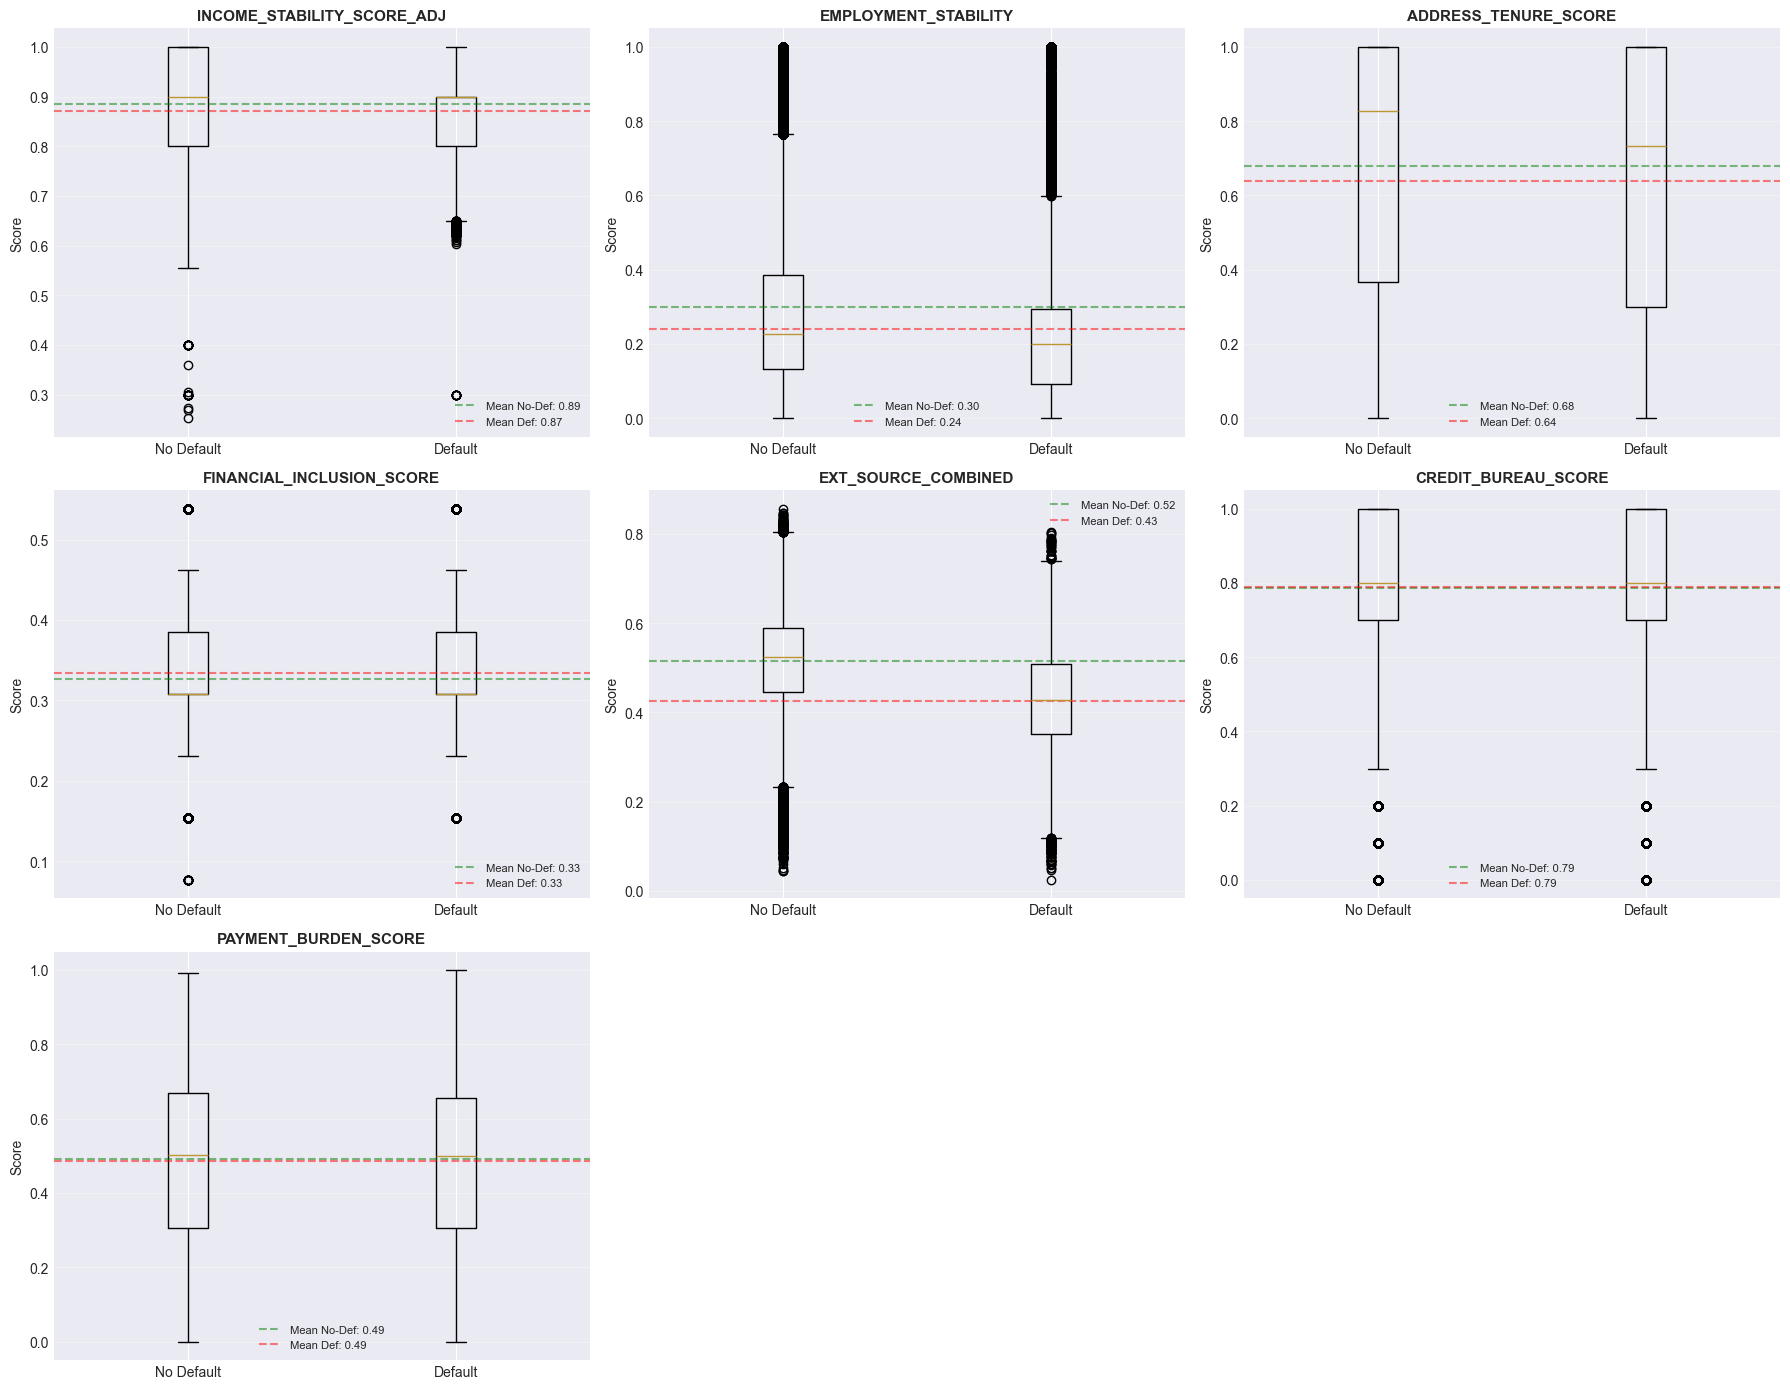


📊 COMPARACIÓN ESTADÍSTICA (Media por grupo):

                   Feature No Default (Media) Default (Media) Diferencia   Dirección
INCOME_STABILITY_SCORE_ADJ              0.886           0.871      0.015 ✅ Protector
      EMPLOYMENT_STABILITY              0.300           0.240      0.060 ✅ Protector
      ADDRESS_TENURE_SCORE              0.681           0.638      0.042 ✅ Protector
 FINANCIAL_INCLUSION_SCORE              0.326           0.334     -0.008   ⚠️ Riesgo
       EXT_SOURCE_COMBINED              0.515           0.426      0.089 ✅ Protector
       CREDIT_BUREAU_SCORE              0.787           0.789     -0.002   ⚠️ Riesgo
      PAYMENT_BURDEN_SCORE              0.491           0.486      0.005 ✅ Protector

💡 INTERPRETACIÓN:
   ✅ Protector: Personas sin default tienen valores MÁS ALTOS
   ⚠️ Riesgo: Personas con default tienen valores MÁS ALTOS


In [13]:
print("\n" + "=" * 80)
print("🎯 ANÁLISIS COMPARATIVO: DEFAULT vs NO-DEFAULT")
print("=" * 80)

# Comparar features alternativos entre defaulters y non-defaulters
comparison_features = alternative_features.copy()

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, feature in enumerate(comparison_features):
    # Datos por target
    no_default = df_fe[df_fe['TARGET'] == 0][feature].dropna()
    default = df_fe[df_fe['TARGET'] == 1][feature].dropna()
    
    # Box plots
    axes[i].boxplot([no_default, default], labels=['No Default', 'Default'])
    axes[i].set_title(feature, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Score')
    axes[i].grid(axis='y', alpha=0.3)
    
    # Añadir medias
    axes[i].axhline(no_default.mean(), color='green', linestyle='--', alpha=0.5,
                    label=f'Mean No-Def: {no_default.mean():.2f}')
    axes[i].axhline(default.mean(), color='red', linestyle='--', alpha=0.5,
                    label=f'Mean Def: {default.mean():.2f}')
    axes[i].legend(fontsize=8)

# Ocultar últimos subplots
for i in range(len(comparison_features), 9):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Tabla estadística
print("\n📊 COMPARACIÓN ESTADÍSTICA (Media por grupo):\n")
comparison_stats = []

for feature in comparison_features:
    no_def_mean = df_fe[df_fe['TARGET'] == 0][feature].mean()
    def_mean = df_fe[df_fe['TARGET'] == 1][feature].mean()
    diff = no_def_mean - def_mean
    
    comparison_stats.append({
        'Feature': feature,
        'No Default (Media)': f"{no_def_mean:.3f}",
        'Default (Media)': f"{def_mean:.3f}",
        'Diferencia': f"{diff:.3f}",
        'Dirección': '✅ Protector' if diff > 0 else '⚠️ Riesgo'
    })

comp_df = pd.DataFrame(comparison_stats)
print(comp_df.to_string(index=False))

print("\n💡 INTERPRETACIÓN:")
print("   ✅ Protector: Personas sin default tienen valores MÁS ALTOS")
print("   ⚠️ Riesgo: Personas con default tienen valores MÁS ALTOS")

### 



---

__Abraham Tartalos \| Data Scientist__

#### 